<a href="https://colab.research.google.com/github/nickocruzm/CS260-Project/blob/main/Josh_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### evaluation metric: AUC

AUC is the probability that your model gives a higher score to a randomly chosen positive than to a randomly chosen negative.

```
AUC = 1.0 — perfect ranking; every positive scores above every negative.
AUC = 0.5 — no better than random guessing (the diagonal line on the plot).
AUC < 0.5 — worse than random, which usually means your labels are flipped.
```


In [ ]:
import kagglehub
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-news-classification' dataset.
Path to dataset files: /kaggle/input/fake-news-classification


In [ ]:
"""
Baseline vs. engineered-feature comparison for fake/real news classification.

Experimental design:
  - ONE locked train/test split, reused across every experiment.
  - ONE fixed model + metric harness, so the ONLY thing that changes between
    runs is the feature set.
  - Three contestants:
        1. TF-IDF (cleaned)    (the baseline to beat)
        2. Engineered features
        3. TF-IDF + engineered
  - Cross-validated scores with standard deviation, because a single AUC
    number is noise, not a result.

Fill in the DATA LOADING section with your own dataframe, then run.
"""

import re
import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction import text as sk_text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb


# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.30
MAX_FEATURES = 5000
CV_FOLDS = 5

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.5,
    "eval_metric": "auc",
    "tree_method": "hist",   # required for GPU; also the fast modern CPU method
    "device": "cuda",        # run training on GPU (XGBoost >= 2.0 syntax)
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
}

# Source/dateline tokens to strip so the model can't cheat on outlet identity.
# Expand this as feature inspection reveals new artifacts.
LEAK_TERMS = {
    "reuters", "reuter", "ap", "afp", "bloomberg", "cnn", "fox",
    "breitbart", "getty", "npr", "newsletter", "subscribe", "featured",
    "pic", "via", "twitter", "photo",
}
CUSTOM_STOP = list(sk_text.ENGLISH_STOP_WORDS.union(LEAK_TERMS))



In [ ]:
# ----------------------------------------------------------------------------
# DATA LOADING
# ----------------------------------------------------------------------------
def load_data():
    """
    Return (texts, labels) where:
      texts  : pandas Series of raw article strings
      labels : pandas Series of 0/1 labels (1 = real, 0 = fake, or your choice)

    Replace the body below with however you load your data, e.g.:
        df = pd.read_csv("news.csv")
        return df["text"], df["label"]
    """
    df = pd.read_csv(f"{path}/WELFake_Dataset.csv")
    df.drop('Unnamed: 0', axis=1, inplace=True)
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)
    df['full_text'] = df['title'] + ' ' + df['text']
    return df['full_text'], df['label'], df # added full df return



# ----------------------------------------------------------------------------
# LEAKAGE CLEANING
# ----------------------------------------------------------------------------
def strip_dateline(text_str):
    """Remove 'CITY (Source) - ' style datelines and residual source parentheticals."""
    if not isinstance(text_str, str):
        return ""
    # Leading "WASHINGTON (Reuters) - " style prefix
    text_str = re.sub(r"^[A-Z][A-Za-z.\s/]+\([^)]*\)\s*[-\u2013\u2014]\s*", "", text_str)
    # Any remaining "(Reuters)" / "(AP)" style parentheticals
    text_str = re.sub(
        r"\([^)]*(reuters|reuter|ap|afp|bloomberg)[^)]*\)",
        "",
        text_str,
        flags=re.IGNORECASE,
    )
    return text_str


# ----------------------------------------------------------------------------
# ENGINEERED FEATURES  (source-independent stylometrics)
# ----------------------------------------------------------------------------

# Stylometrics (or stylometry) is the statistical and computational study of linguistic style.

def extract_features(text_str):
    """Turn one article into a dict of style/structure features."""
    if not isinstance(text_str, str):
        text_str = ""
    words = text_str.split()
    sentences = [s for s in re.split(r"[.!?]+", text_str) if s.strip()]
    n_words = len(words) or 1
    n_sents = len(sentences) or 1
    n_chars = len(text_str) or 1

    # Features

    lower_words = [w.lower() for w in words]

    pronouns = {"i", "me", "my", "mine", "we", "us", "our", "ours", "you", "your", "yours", "he", "him", "his", "she", "her", "hers", "they", "them", "their", "theirs"}
    negations = {"no", "not", "never", "none", "nobody", "nothing", "neither", "nor", "cannot", "can't", "won't", "don't", "doesn't", "didn't"}
    certainty = {"always", "definitely", "certainly", "clearly", "obviously", "undeniably", "surely", "must"}
    hedging = {"may", "might", "could", "possibly", "perhaps", "apparently", "seems", "likely", "allegedly", "reportedly"}
    superlatives = {"best", "worst", "greatest", "least", "most", "biggest", "smallest", "highest", "lowest"}
    sensational = {"shocking", "unbelievable", "explosive", "incredible", "breaking", "scandal", "bombshell", "outrage", "secret", "exposed"}

    return {
        "n_words": len(words),
        # "n_sentences": len(sentences),                                  # overlaps with n_words
        "avg_word_len": np.mean([len(w) for w in words]) if words else 0.0,
        # "avg_sent_len": n_words / n_sents,                              # derived
        "exclaim_rate": text_str.count("!") / n_words,
        "question_rate": text_str.count("?") / n_words,
        #"quote_rate": text_str.count('"') / n_words,                     # weak metric
        # "caps_word_rate": sum(w.isupper() and len(w) > 1 for w in words) / n_words, # probably useless
        # "digit_rate": sum(c.isdigit() for c in text_str) / n_chars,     # weak metric
        "type_token_ratio": len(set(w.lower() for w in words)) / n_words,


        "pronoun_rate": sum(w in pronouns for w in lower_words) / n_words,
        # "negation_rate": sum(w in negations for w in lower_words) / n_words,
        "certainty_rate": sum(w in certainty for w in lower_words) / n_words,
        "hedging_rate": sum(w in hedging for w in lower_words) / n_words,
        "superlative_rate": sum(w in superlatives for w in lower_words) / n_words,
        "sensational_rate": sum(w in sensational for w in lower_words) / n_words,
        # "number_word_rate": sum(w.isdigit() for w in lower_words) / n_words,
        #"percent_symbol_rate": text_str.count("%") / n_words,
        #"currency_symbol_rate": sum(text_str.count(s) for s in ["$", "€", "£"]) / n_words,
    }


def build_feature_frame(texts):
    """Vectorized application of extract_features over a text Series."""
    return texts.apply(lambda t: pd.Series(extract_features(t)))


# ----------------------------------------------------------------------------
# EVALUATION HARNESS  (identical for every feature set)
# ----------------------------------------------------------------------------
def make_model():
    return xgb.XGBClassifier(**XGB_PARAMS)


def evaluate(X_train, X_test, y_train, y_test, label, results):
    """Train once on the locked split, score AUC on the held-out test set."""
    model = make_model()
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    preds = model.predict(X_test)

    print(f"\n{'=' * 60}")
    print(f"  {label}")
    print(f"{'=' * 60}")
    print(f"  Held-out AUC: {auc:.4f}")
    print("  Confusion matrix:")
    print(confusion_matrix(y_test, preds))
    print("  Classification report:")
    print(classification_report(y_test, preds, digits=3))

    results.append({"experiment": label, "holdout_auc": auc, "model": model})
    return model


def cross_validate(X, y, label, results_cv):
    """Cross-validated AUC with spread, so we can tell signal from noise."""
    scores = cross_val_score(
        make_model(), X, y, cv=CV_FOLDS, scoring="roc_auc", n_jobs=-1
    )
    print(f"  {label:28s} CV AUC: {scores.mean():.4f} +/- {scores.std():.4f}")
    results_cv.append(
        {"experiment": label, "cv_mean": scores.mean(), "cv_std": scores.std()}
    )



In [ ]:
# ----------------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------------

# --- load + clean -------------------------------------------------------
texts, labels, df = load_data() # added df variable assignment
texts = texts.reset_index(drop=True)
labels = labels.reset_index(drop=True)
print(f"Loaded {len(texts)} articles.")
print("Class balance:")
print(labels.value_counts(normalize=True).round(3).to_string())

text_clean = texts.apply(strip_dateline)

# --- lock the split ONCE on raw indices ---------------------------------
train_idx, test_idx = train_test_split(
    np.arange(len(texts)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)
y_train = labels.iloc[train_idx]
y_test = labels.iloc[test_idx]
print(f"\nTrain: {len(train_idx)}  Test: {len(test_idx)}")
print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  balance:", y_test.value_counts(normalize=True).round(3).to_dict())

holdout_results = []
cv_results = []



Loaded 63121 articles.
Class balance:
label
0    0.551
1    0.449

Train: 44184  Test: 18937
Train balance: {0: 0.551, 1: 0.449}
Test  balance: {0: 0.551, 1: 0.449}


In [ ]:
# --- 1. BASELINE: TF-IDF (cleaned) --------------------------------------
vec = TfidfVectorizer(max_features=MAX_FEATURES, stop_words=CUSTOM_STOP)
Xtrain_tfidf = vec.fit_transform(text_clean.iloc[train_idx])
Xtest_tfidf = vec.transform(text_clean.iloc[test_idx])
evaluate(Xtrain_tfidf, Xtest_tfidf, y_train, y_test,
            "BASELINE: TF-IDF (cleaned)", holdout_results)


  BASELINE: TF-IDF (cleaned)
  Held-out AUC: 0.5940
  Confusion matrix:
[[9751  687]
 [6355 2144]]
  Classification report:
              precision    recall  f1-score   support

           0      0.605     0.934     0.735     10438
           1      0.757     0.252     0.378      8499

    accuracy                          0.628     18937
   macro avg      0.681     0.593     0.557     18937
weighted avg      0.674     0.628     0.575     18937



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [22:50:39] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# --- 2. CHALLENGER: engineered features ---------------------------------
feature_df = build_feature_frame(text_clean)
Xtrain_eng = feature_df.iloc[train_idx].values
Xtest_eng = feature_df.iloc[test_idx].values
eng_model = evaluate(Xtrain_eng, Xtest_eng, y_train, y_test,
                        "CHALLENGER: Engineered features", holdout_results)


  CHALLENGER: Engineered features
  Held-out AUC: 0.8420
  Confusion matrix:
[[8580 1858]
 [2374 6125]]
  Classification report:
              precision    recall  f1-score   support

           0      0.783     0.822     0.802     10438
           1      0.767     0.721     0.743      8499

    accuracy                          0.777     18937
   macro avg      0.775     0.771     0.773     18937
weighted avg      0.776     0.777     0.776     18937



In [ ]:
# --- 3. COMBINED: TF-IDF + engineered -----------------------------------
Xtrain_comb = hstack([Xtrain_tfidf, csr_matrix(Xtrain_eng)])
Xtest_comb = hstack([Xtest_tfidf, csr_matrix(Xtest_eng)])
evaluate(Xtrain_comb, Xtest_comb, y_train, y_test,
            "COMBINED: TF-IDF + engineered", holdout_results)


  COMBINED: TF-IDF + engineered
  Held-out AUC: 0.5941
  Confusion matrix:
[[8071 2367]
 [5013 3486]]
  Classification report:
              precision    recall  f1-score   support

           0      0.617     0.773     0.686     10438
           1      0.596     0.410     0.486      8499

    accuracy                          0.610     18937
   macro avg      0.606     0.592     0.586     18937
weighted avg      0.607     0.610     0.596     18937



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# --- cross-validation (signal vs. noise check) --------------------------
print(f"\n{'=' * 60}")
print("  CROSS-VALIDATED AUC  (mean +/- std over folds)")
print(f"{'=' * 60}")
# Rebuild full-data matrices for CV (vectorizer refit inside each fold would
# be ideal via a Pipeline; here we use a single fit for a quick variance read).
X_tfidf_all = vec.fit_transform(text_clean)
X_eng_all = feature_df.values
X_comb_all = hstack([X_tfidf_all, csr_matrix(X_eng_all)])
cross_validate(X_tfidf_all, labels, "TF-IDF (cleaned)", cv_results)
cross_validate(X_eng_all, labels, "Engineered", cv_results)
cross_validate(X_comb_all, labels, "TF-IDF + engineered", cv_results)


  CROSS-VALIDATED AUC  (mean +/- std over folds)
  TF-IDF (cleaned)             CV AUC: 0.6741 +/- 0.0621
  Engineered                   CV AUC: 0.8439 +/- 0.0039
  TF-IDF + engineered          CV AUC: 0.6092 +/- 0.0702


In [ ]:
# --- engineered feature directions (interpretability payoff) ------------
print(f"\n{'=' * 60}")
print("  ENGINEERED FEATURE DIRECTIONS  (train set per-class means)")
print(f"{'=' * 60}")
classes = sorted(labels.unique())
train_feats = feature_df.iloc[train_idx]
header = f"  {'feature':18s}" + "".join(f"  class={c}" for c in classes)
print(header)
for col in feature_df.columns:
    means = [train_feats[y_train.values == c][col].mean() for c in classes]
    row = f"  {col:18s}" + "".join(f"  {m:9.3f}" for m in means)
    print(row)


  ENGINEERED FEATURE DIRECTIONS  (train set per-class means)
  feature             class=0  class=1
  n_words               583.281    521.613
  avg_word_len            5.098      5.075
  exclaim_rate            0.000      0.004
  question_rate           0.001      0.003
  type_token_ratio        0.588      0.604
  pronoun_rate            0.028      0.042
  certainty_rate          0.001      0.001
  hedging_rate            0.003      0.003
  superlative_rate        0.002      0.002
  sensational_rate        0.000      0.001


In [ ]:

importances = eng_model.feature_importances_
print("\n  Engineered feature importances (challenger model):")
order = np.argsort(importances)[::-1]
for i in order:
    print(f"    {feature_df.columns[i]:18s} {importances[i]:.3f}")


  Engineered feature importances (challenger model):
    exclaim_rate       0.352
    question_rate      0.166
    n_words            0.096
    sensational_rate   0.076
    pronoun_rate       0.066
    avg_word_len       0.054
    type_token_ratio   0.053
    certainty_rate     0.049
    superlative_rate   0.044
    hedging_rate       0.043


In [ ]:
# --- final comparison table ---------------------------------------------
print(f"\n{'=' * 60}")
print("  SUMMARY  (did the challenger beat the baseline?)")
print(f"{'=' * 60}")
summary = pd.DataFrame(
    [{"experiment": r["experiment"], "holdout_auc": round(r["holdout_auc"], 4)}
        for r in holdout_results]
).merge(
    pd.DataFrame(cv_results).assign(
        cv=lambda d: d["cv_mean"].round(4).astype(str)
        + " +/- " + d["cv_std"].round(4).astype(str)
    )[["experiment", "cv"]],
    on="experiment", how="left",
)
print(summary.to_string(index=False))

baseline_auc = holdout_results[0]["holdout_auc"]
print(f"\n  Baseline (TF-IDF) held-out AUC: {baseline_auc:.4f}")
for r in holdout_results[1:]:
    delta = r["holdout_auc"] - baseline_auc
    verdict = "BEATS baseline" if delta > 0 else "below baseline"
    print(f"  {r['experiment']:35s} {delta:+.4f}  ({verdict})")
print("\n  NOTE: a difference smaller than the CV std is noise, not a win.")


  SUMMARY  (did the challenger beat the baseline?)
                     experiment  holdout_auc  cv
     BASELINE: TF-IDF (cleaned)       0.5940 NaN
CHALLENGER: Engineered features       0.8420 NaN
  COMBINED: TF-IDF + engineered       0.5941 NaN

  Baseline (TF-IDF) held-out AUC: 0.5940
  CHALLENGER: Engineered features     +0.2480  (BEATS baseline)
  COMBINED: TF-IDF + engineered       +0.0001  (BEATS baseline)

  NOTE: a difference smaller than the CV std is noise, not a win.


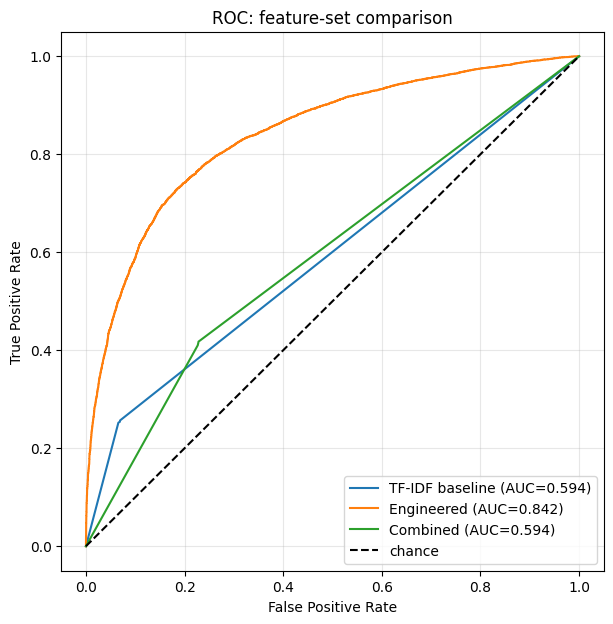

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 7))
for name, (Xtr, Xte) in {
    "TF-IDF baseline": (Xtrain_tfidf, Xtest_tfidf),
    "Engineered":      (Xtrain_eng,   Xtest_eng),
    "Combined":        (Xtrain_comb,  Xtest_comb),
}.items():
    m = make_model().fit(Xtr, y_train)
    scores = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, scores):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: feature-set comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#Features

"n_words": len(words), \
        "n_sentences": len(sentences), \
        "avg_word_len": np.mean([len(w) for w in words]) if words else 0.0, \
        "avg_sent_len": n_words / n_sents, \
        "exclaim_rate": text_str.count("!") / n_words, \
        "question_rate": text_str.count("?") / n_words, \
        "quote_rate": text_str.count('"') / n_words, \
        "caps_word_rate": sum(w.isupper() and len(w) > 1 for w in words) / n_words, \
        "digit_rate": sum(c.isdigit() for c in text_str) / n_chars,\
        "type_token_ratio": len(set(w.lower() for w in words)) / n_words, \

*AUC is the primary metric used to measure how effectively a feature or feature set enables the model to distinguish between real and fake news articles.*

In [ ]:
single_feature = feature_df[["avg_word_len"]]

evaluate(
    single_feature.iloc[train_idx],
    single_feature.iloc[test_idx],
    y_train,
    y_test,
    "Average Word Length Only",
    []
)


  Average Word Length Only
  Held-out AUC: 0.6072
  Confusion matrix:
[[8245 2193]
 [5278 3221]]
  Classification report:
              precision    recall  f1-score   support

           0      0.610     0.790     0.688     10438
           1      0.595     0.379     0.463      8499

    accuracy                          0.605     18937
   macro avg      0.602     0.584     0.576     18937
weighted avg      0.603     0.605     0.587     18937



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
single_feature = feature_df[["n_words"]]

evaluate(
    single_feature.iloc[train_idx],
    single_feature.iloc[test_idx],
    y_train,
    y_test,
    "Type Token Ratio Only",
    []
)


  Type Token Ratio Only
  Held-out AUC: 0.6453
  Confusion matrix:
[[6993 3445]
 [4095 4404]]
  Classification report:
              precision    recall  f1-score   support

           0      0.631     0.670     0.650     10438
           1      0.561     0.518     0.539      8499

    accuracy                          0.602     18937
   macro avg      0.596     0.594     0.594     18937
weighted avg      0.599     0.602     0.600     18937



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

Number of tests: 1023

There are $10$ total features. Each features has $2$ choices: *include* or *don't include*

<br>

*   *Feature 1* : $2$ choices
*   *Feature 2* : $2$ choices
*   ...
*   *Feature 10* : $2$ choices
<br>

So we check: $2 \cdot 2 \cdot 2 \cdot ... \cdot 2$ for all $10$ features.
<br>
$10^2$ = 1024
<br>
<br>

We subtract the case of nothing

$1024 - 1 = 1023$

<br>

**So, there are $1023$ total tests**

In [ ]:
from tqdm.notebook import tqdm
from itertools import combinations
from contextlib import redirect_stdout
import io

feature_cols = feature_df.columns.tolist()

all_combos = [
    combo
    for r in range(1, len(feature_cols) + 1)
    for combo in combinations(feature_cols, r)
]

combo_results = []

for combo in tqdm(all_combos):
    temp_results = []
    X_combo = feature_df[list(combo)]

    with redirect_stdout(io.StringIO()): # suppresses evaluate's print output
        evaluate(
            X_combo.iloc[train_idx],
            X_combo.iloc[test_idx],
            y_train,
            y_test,
            " + ".join(combo),
            temp_results
        )

    combo_results.extend(temp_results)

  0%|          | 0/1023 [00:00<?, ?it/s]

To display a table of the results

In [ ]:
import pandas as pd

results_table = (
    pd.DataFrame(combo_results)[["experiment", "holdout_auc"]]
    .rename(columns={
        "experiment": "Features Used",
        "holdout_auc": "AUC"
    })
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

display(results_table)

,Features Used,AUC
0,n_words + avg_word_len + exclaim_rate + questi...,0.843087
1,n_words + avg_word_len + exclaim_rate + questi...,0.843025
2,n_words + avg_word_len + exclaim_rate + questi...,0.842031
3,n_words + avg_word_len + exclaim_rate + questi...,0.841979
4,n_words + avg_word_len + exclaim_rate + questi...,0.840234
...,...,...
1018,hedging_rate + sensational_rate,0.555331
1019,sensational_rate,0.545170
1020,hedging_rate + superlative_rate,0.543428
1021,superlative_rate,0.541615


Download the data

In [ ]:
results_table.to_csv("feature_auc_results.csv", index=False)

In [ ]:
from google.colab import files
files.download("feature_auc_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>